# Willett Representation Manifolds

Export hidden states and phoneme predictions from trained Willett-style GRU/S5 decoders, then run first-pass low-dimensional analyses using broad phonetic categories rather than hard phoneme-window alignment.

The important contract is: extraction writes durable per-model artifacts under Drive, and analysis cells read those artifacts without touching checkpoints again.

In [2]:
# Colab / Drive / repo bootstrap.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print(f'Not running in Colab or Drive already unavailable: {exc}')

import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = Path('/content/utah-ssl') if Path('/content').exists() else Path.cwd()
REPO_URL = 'https://github.com/ethan-read/utah-ssl.git'

if str(REPO_DIR).startswith('/content'):
    if not REPO_DIR.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', 'pull', '--ff-only'], cwd=str(REPO_DIR), check=False)

os.chdir(REPO_DIR)
PACKAGE_ROOT = REPO_DIR
os.environ['PYTHONPATH'] = f"{PACKAGE_ROOT}:{os.environ.get('PYTHONPATH', '')}"
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

# pyarrow is optional; without it the exporter still writes CSV tables.
try:
    import pyarrow  # noqa: F401
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'pyarrow'], check=False)

print('REPO_DIR:', REPO_DIR)
print('PACKAGE_ROOT:', PACKAGE_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_DIR: /content/utah-ssl
PACKAGE_ROOT: /content/utah-ssl


In [3]:
from pathlib import Path

# Drive/local roots. Edit these in one place if your Drive layout differs.
DRIVE_ROOT = Path('/content/drive/MyDrive') if Path('/content/drive/MyDrive').exists() else Path('/Users/home/My Drive')
UTAH_SSL_ROOT = DRIVE_ROOT / 'utah_ssl'
RAW_CACHE_ROOT = UTAH_SSL_ROOT / 'data' / 'cache_v1'
REPRESENTATION_ROOT = UTAH_SSL_ROOT / 'data' / 'representations' / 'willett_manifolds'

# The released Stanford RNN checkpoint is distributed as TensorFlow ckpt-* files
# inside derived.tar.gz. We convert it once to a PyTorch checkpoint and then use
# the same PyTorch representation exporter as the locally trained GRU/S5 runs.
LOCAL_WILLETT_DIR = REPO_DIR / 'experiments' / 'supervised_baselines'
RELEASED_DERIVED_ARCHIVE_CANDIDATES = [
    LOCAL_WILLETT_DIR / 'derived.tar.gz',
    DRIVE_ROOT / 'willett reconstruction' / 'derived.tar.gz',
    DRIVE_ROOT / 'Willett Reconstruction' / 'derived.tar.gz',
    DRIVE_ROOT / 'willett_reconstruction' / 'derived.tar.gz',
    UTAH_SSL_ROOT / 'willett_reconstruction' / 'derived.tar.gz',
    UTAH_SSL_ROOT / 'data' / 'willett_reconstruction' / 'derived.tar.gz',
]
RELEASED_DERIVED_ARCHIVE = next(
    (path for path in RELEASED_DERIVED_ARCHIVE_CANDIDATES if path.exists()),
    RELEASED_DERIVED_ARCHIVE_CANDIDATES[0],
)
RELEASED_DERIVED_ROOT_CANDIDATES = [
    archive.parent / 'derived' for archive in RELEASED_DERIVED_ARCHIVE_CANDIDATES
]
def has_released_baseline_checkpoint(root):
    baseline_dir = root / 'rnns' / 'baselineRelease'
    return (baseline_dir / 'checkpoint').exists() and (baseline_dir / 'args.yaml').exists()

RELEASED_DERIVED_ROOT = next(
    (root for root in RELEASED_DERIVED_ROOT_CANDIDATES if has_released_baseline_checkpoint(root)),
    RELEASED_DERIVED_ARCHIVE.parent / 'derived',
)
RELEASED_RNN_PT_CHECKPOINT = UTAH_SSL_ROOT / 'outputs' / 'willett_reconstruction' / 'stanford_released_baseline_rnn' / 'checkpoint_released_ckpt9950.pt'
CONVERT_RELEASED_RNN = True
OVERWRITE_RELEASED_RNN_CONVERSION = False

EXPORT_NAME = 'stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1'
EXPORT_ROOT = REPRESENTATION_ROOT / EXPORT_NAME

DATASET = 'brain2text24'
EXPORT_SPLIT = 'val'
MAX_EXAMPLES = None      # set to a small int, e.g. 16, for a smoke extraction
BATCH_SIZE = 32
SHARD_SIZE_TOKENS = 50_000
OVERWRITE_EXPORT = False
DEVICE = None           # None auto-detects cuda/mps/cpu
BIN_SIZE_MS = 20
SAVE_INPUT_WINDOWS = True  # Save normalized neural windows aligned to each predicted-phoneme logit row.

# For analysis-only reruns, leave this as None to load every model folder under
# EXPORT_ROOT that has metadata.json. Set an explicit tuple to control order.
ANALYSIS_MODEL_KEYS = None  # e.g. ('gru', 's5', 'gru_released')

# Stanford release note: the TFRecord inputFeatures are 256-D, corresponding to
# area-6v TX + spike-band power after the repository's area6v migration. In our
# cache vocabulary this is feature_mode='tx_sbp', not tx_only.
RELEASED_RNN_FEATURE_MODE = 'tx_sbp'
# Restrict all manifold exports to the sessions covered by the released RNN input adapters.
RELEASED_SESSION_FILTER = None  # populated from experiments.supervised_baselines.RELEASED_SESSIONS below

MODEL_CANDIDATES = {
    's5': [
        UTAH_SSL_ROOT / 'outputs' / 'ssl_experiments' / 'willett_s5_tx_sbp' / 'willett_s5_tx_sbp_seed7_60k' / 'checkpoint_best.pt',
        UTAH_SSL_ROOT / 'outputs' / 'willett_s5_reconstruction' / '*' / 'checkpoint_best.pt',
    ],
}

# Optional Brain2Text25 Colab run export. This computes a fresh representation
# table from the checkpoint produced by notebooks/willett_gru_baseline.ipynb, then
# makes it available to the same PCA/plotting cells below.
B2T25_EXPORT_ENABLED = False
B2T25_MODEL_KEY = 'gru_b2t25_colab_best'
B2T25_EXPORT_NAME = 'b2t25_gru_tx_sbp_source_train_val_manifold_v1'
B2T25_EXPORT_ROOT = REPRESENTATION_ROOT / B2T25_EXPORT_NAME
B2T25_CHECKPOINT_CANDIDATES = [
    UTAH_SSL_ROOT / 'outputs' / 'willett_reconstruction' / 'willett_b2t25_tx_sbp_source_train_val_colab' / 'checkpoint_best.pt',
    UTAH_SSL_ROOT / 'outputs' / 'willett_reconstruction' / 'willett_b2t25_tx_sbp_source_train_val_colab' / 'checkpoint_final.pt',
]
B2T25_MAX_EXAMPLES = MAX_EXAMPLES
B2T25_BATCH_SIZE = BATCH_SIZE
B2T25_SHARD_SIZE_TOKENS = SHARD_SIZE_TOKENS
B2T25_OVERWRITE_EXPORT = False
B2T25_SAVE_INPUT_WINDOWS = SAVE_INPUT_WINDOWS

# Set to None to plot every loaded model, or e.g. ('gru_b2t25_colab_best',)
# to focus on the new Brain2Text25 run.
PLOT_MODEL_KEYS = None

EXPORT_ROOT

PosixPath('/content/drive/MyDrive/utah_ssl/data/representations/willett_manifolds/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1')

In [4]:
import glob
import json
import subprocess
import sys
from IPython.display import display
import pandas as pd


def resolve_candidates(candidates):
    rows = []
    for candidate in candidates:
        candidate = Path(candidate)
        matches = sorted(Path(path) for path in glob.glob(str(candidate))) if '*' in str(candidate) else [candidate]
        for path in matches:
            rows.append({'candidate': str(path), 'exists': path.exists()})
    existing = [Path(row['candidate']) for row in rows if row['exists']]
    return (existing[0] if existing else None), pd.DataFrame(rows)


def ensure_released_checkpoint_conversion_deps():
    missing = []
    try:
        import tensorflow  # noqa: F401
    except Exception:
        missing.append('tensorflow-cpu')
    try:
        import yaml  # noqa: F401
    except Exception:
        missing.append('pyyaml')
    if missing:
        print('Installing one-time released-checkpoint conversion dependencies:', missing)
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)


resolved_checkpoints = {}
resolution_tables = []

if CONVERT_RELEASED_RNN:
    ensure_released_checkpoint_conversion_deps()
    from experiments.supervised_baselines import (
        RELEASED_SESSIONS,
        convert_released_tf_checkpoint_to_pytorch,
        ensure_released_archive_extracted,
    )
    RELEASED_SESSION_FILTER = tuple(RELEASED_SESSIONS)

    if RELEASED_RNN_PT_CHECKPOINT.exists() and not OVERWRITE_RELEASED_RNN_CONVERSION:
        released_checkpoint = RELEASED_RNN_PT_CHECKPOINT
        print('Using existing converted released RNN checkpoint:', released_checkpoint)
    else:
        if not has_released_baseline_checkpoint(RELEASED_DERIVED_ROOT) and not RELEASED_DERIVED_ARCHIVE.exists():
            checked_archives = '\n  - '.join(str(path) for path in RELEASED_DERIVED_ARCHIVE_CANDIDATES)
            checked_roots = '\n  - '.join(str(path) for path in RELEASED_DERIVED_ROOT_CANDIDATES)
            raise FileNotFoundError(
                'Released Willett weights are not available yet. Either create the converted PyTorch checkpoint at\n'
                f'  {RELEASED_RNN_PT_CHECKPOINT}\n'
                'or upload/extract the TensorFlow checkpoint folder so one of these derived roots exists:\n'
                f'  - {checked_roots}\n'
                'or upload derived.tar.gz to one of these archive paths:\n'
                f'  - {checked_archives}'
            )
        print('Using released derived archive:', RELEASED_DERIVED_ARCHIVE)
        derived_root = ensure_released_archive_extracted(
            archive_path=RELEASED_DERIVED_ARCHIVE,
            derived_root=RELEASED_DERIVED_ROOT,
        )
        released_checkpoint = convert_released_tf_checkpoint_to_pytorch(
            checkpoint_dir=derived_root / 'rnns' / 'baselineRelease',
            output_path=RELEASED_RNN_PT_CHECKPOINT,
            cache_root=RAW_CACHE_ROOT,
            overwrite=OVERWRITE_RELEASED_RNN_CONVERSION,
        )
    resolved_checkpoints['gru_released'] = released_checkpoint
    resolution_tables.append(pd.DataFrame([{
        'model_key': 'gru_released',
        'candidate': str(released_checkpoint),
        'exists': Path(released_checkpoint).exists(),
        'source': 'Stanford released TensorFlow ckpt converted to PyTorch',
        'feature_mode': RELEASED_RNN_FEATURE_MODE,
    }]))

if not CONVERT_RELEASED_RNN:
    RELEASED_SESSION_FILTER = None

for model_key, candidates in MODEL_CANDIDATES.items():
    resolved, table = resolve_candidates(candidates)
    table.insert(0, 'model_key', model_key)
    resolution_tables.append(table)
    if resolved is not None:
        resolved_checkpoints[model_key] = resolved

checkpoint_resolution = pd.concat(resolution_tables, ignore_index=True) if resolution_tables else pd.DataFrame()
display(checkpoint_resolution)
print('Resolved checkpoints:')
print(json.dumps({key: str(value) for key, value in resolved_checkpoints.items()}, indent=2))

if not resolved_checkpoints:
    raise FileNotFoundError('No checkpoints resolved. Check RELEASED_DERIVED_ARCHIVE and MODEL_CANDIDATES above.')

Using existing converted released RNN checkpoint: /content/drive/MyDrive/utah_ssl/outputs/willett_reconstruction/stanford_released_baseline_rnn/checkpoint_released_ckpt9950.pt


,model_key,candidate,exists,source,feature_mode
0,gru_released,/content/drive/MyDrive/utah_ssl/outputs/willet...,True,Stanford released TensorFlow ckpt converted to...,tx_sbp
1,s5,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,False,NaN,NaN
2,s5,/content/drive/MyDrive/utah_ssl/outputs/willet...,True,NaN,NaN


Resolved checkpoints:
{
  "gru_released": "/content/drive/MyDrive/utah_ssl/outputs/willett_reconstruction/stanford_released_baseline_rnn/checkpoint_released_ckpt9950.pt",
  "s5": "/content/drive/MyDrive/utah_ssl/outputs/willett_s5_reconstruction/willett_s5_tx_only_causal_20260602T211412Z/checkpoint_best.pt"
}


## Export Representations

This cell is the durable extraction step. It rebuilds each model from its checkpoint config, applies the same eval-time preprocessing as Willett validation, and writes hidden/logit shards plus token/example tables.

In [6]:
from experiments.manifolds.representation_export import RepresentationExportConfig, export_willett_representations

export_summaries = {}
for model_key, checkpoint_path in resolved_checkpoints.items():
    print(f'\n=== exporting {model_key}: {checkpoint_path} ===')
    summary = export_willett_representations(
        RepresentationExportConfig(
            checkpoint_path=checkpoint_path,
            export_root=EXPORT_ROOT,
            model_key=model_key,
            split=EXPORT_SPLIT,
            allowed_session_ids=RELEASED_SESSION_FILTER,
            max_examples=MAX_EXAMPLES,
            batch_size=BATCH_SIZE,
            shard_size_tokens=SHARD_SIZE_TOKENS,
            bin_size_ms=BIN_SIZE_MS,
            overwrite=OVERWRITE_EXPORT,
            device=DEVICE,
            repo_dir=REPO_DIR,
            cache_root_override=RAW_CACHE_ROOT,
            save_input_windows=SAVE_INPUT_WINDOWS,
        )
    )
    export_summaries[model_key] = summary
    print(json.dumps({
        'model_key': model_key,
        'export_dir': str(EXPORT_ROOT / model_key),
        'example_count': summary.get('example_count'),
        'token_count': summary.get('token_count'),
        'hidden_dim': summary.get('hidden_dim'),
        'input_window_dim': summary.get('input_window_dim'),
        'adapted_input_window_dim': summary.get('adapted_input_window_dim'),
        'checkpoint_step': summary.get('checkpoint_step'),
        'feature_mode': summary.get('feature_mode'),
    }, indent=2))


=== exporting gru_released: /content/drive/MyDrive/utah_ssl/outputs/willett_reconstruction/stanford_released_baseline_rnn/checkpoint_released_ckpt9950.pt ===
{
  "model_key": "gru_released",
  "export_dir": "/content/drive/MyDrive/utah_ssl/data/representations/willett_manifolds/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1/gru_released",
  "example_count": 680,
  "token_count": 47432,
  "hidden_dim": 1024,
  "input_window_dim": 8192,
  "adapted_input_window_dim": 8192,
  "checkpoint_step": 9950,
  "feature_mode": "tx_sbp"
}

=== exporting s5: /content/drive/MyDrive/utah_ssl/outputs/willett_s5_reconstruction/willett_s5_tx_only_causal_20260602T211412Z/checkpoint_best.pt ===
{
  "model_key": "s5",
  "export_dir": "/content/drive/MyDrive/utah_ssl/data/representations/willett_manifolds/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1/s5",
  "example_count": 680,
  "token_count": 50511,
  "hidden_dim": 512,
  "input_window_dim": 1792,
  "adapted_input_window

## Load Exported Artifacts

Everything below uses the saved artifacts, not the model checkpoints.

In [6]:
import json
import numpy as np
import pandas as pd
from pathlib import Path


def load_model_export(export_root, model_key, *, load_input_windows=False):
    model_dir = Path(export_root) / model_key
    metadata = json.loads((model_dir / 'metadata.json').read_text())
    tokens = pd.read_csv(model_dir / 'tokens.csv')
    examples = pd.read_csv(model_dir / 'examples.csv')
    shard_rows = json.loads((model_dir / 'shards.json').read_text())
    hidden_parts = []
    logits_parts = []
    input_window_parts = []
    adapted_input_window_parts = []
    for shard in shard_rows:
        arrays = np.load(model_dir / 'shards' / shard['shard'])
        hidden_parts.append(arrays['hidden'])
        logits_parts.append(arrays['logits'])
        if load_input_windows and 'input_windows' in arrays:
            input_window_parts.append(arrays['input_windows'])
        if load_input_windows and 'adapted_input_windows' in arrays:
            adapted_input_window_parts.append(arrays['adapted_input_windows'])
    hidden = np.concatenate(hidden_parts, axis=0) if hidden_parts else np.zeros((0, 0), dtype=np.float32)
    logits = np.concatenate(logits_parts, axis=0) if logits_parts else np.zeros((0, 0), dtype=np.float32)
    input_windows = np.concatenate(input_window_parts, axis=0) if input_window_parts else None
    adapted_input_windows = np.concatenate(adapted_input_window_parts, axis=0) if adapted_input_window_parts else None
    if hidden.shape[0] != tokens.shape[0]:
        raise ValueError(f'{model_key}: hidden rows {hidden.shape[0]} != token rows {tokens.shape[0]}')
    if input_windows is not None and input_windows.shape[0] != tokens.shape[0]:
        raise ValueError(f'{model_key}: input-window rows {input_windows.shape[0]} != token rows {tokens.shape[0]}')
    if adapted_input_windows is not None and adapted_input_windows.shape[0] != tokens.shape[0]:
        raise ValueError(f'{model_key}: adapted-input-window rows {adapted_input_windows.shape[0]} != token rows {tokens.shape[0]}')
    return {
        'metadata': metadata,
        'tokens': tokens,
        'examples': examples,
        'hidden': hidden,
        'logits': logits,
        'input_windows': input_windows,
        'adapted_input_windows': adapted_input_windows,
    }


def discover_model_exports(export_root):
    root = Path(export_root)
    if not root.exists():
        raise FileNotFoundError(f'Export root does not exist: {root}')
    return tuple(
        sorted(
            path.name
            for path in root.iterdir()
            if path.is_dir() and (path / 'metadata.json').exists()
        )
    )


extra_export_roots_by_model = dict(globals().get('extra_export_roots_by_model', {}))
if 'B2T25_MODEL_KEY' in globals() and 'B2T25_EXPORT_ROOT' in globals():
    extra_export_roots_by_model.setdefault(B2T25_MODEL_KEY, B2T25_EXPORT_ROOT)
base_model_keys = discover_model_exports(EXPORT_ROOT)
extra_model_keys = tuple(
    model_key
    for model_key, root in extra_export_roots_by_model.items()
    if (Path(root) / model_key / 'metadata.json').exists()
)

available_model_keys = tuple(dict.fromkeys(base_model_keys + extra_model_keys))
analysis_model_keys = (
    tuple(ANALYSIS_MODEL_KEYS)
    if ANALYSIS_MODEL_KEYS is not None
    else available_model_keys
)
if not analysis_model_keys:
    raise FileNotFoundError(
        f'No saved model exports found under {EXPORT_ROOT} or extra export roots: '
        f'{extra_export_roots_by_model}'
    )


def export_root_for_model(model_key):
    return Path(extra_export_roots_by_model.get(model_key, EXPORT_ROOT))


exports = {
    model_key: load_model_export(export_root_for_model(model_key), model_key, load_input_windows=False)
    for model_key in analysis_model_keys
}
summary_rows = []
for model_key, payload in exports.items():
    meta = payload['metadata']
    summary_rows.append({
        'model': model_key,
        'export_root': str(export_root_for_model(model_key)),
        'dataset': meta.get('dataset'),
        'examples': meta['example_count'],
        'tokens': meta['token_count'],
        'hidden_dim': meta['hidden_dim'],
        'input_window_dim': meta.get('input_window_dim'),
        'adapted_input_window_dim': meta.get('adapted_input_window_dim'),
        'checkpoint_step': meta['checkpoint_step'],
        'patch_ms': meta['patch_size_ms'],
        'stride_ms': meta['patch_stride_ms'],
    })
display(pd.DataFrame(summary_rows))


,model,examples,tokens,hidden_dim,input_window_dim,adapted_input_window_dim,checkpoint_step,patch_ms,stride_ms
0,gru,680,50511,512,3584,3584,9300,280,80
1,gru_released,680,47432,1024,8192,8192,9950,640,80
2,s5,680,50511,512,1792,3584,11200,280,80


## PCA Views

These are descriptive projections. Interpret color gradients more than apparent clusters.

gru explained variance: [0.2475 0.1701 0.0697]
gru_latest_step_020000 explained variance: [0.2297 0.1488 0.0673]
gru_released explained variance: [0.1557 0.1104 0.0686]
s5 explained variance: [0.1063 0.0547 0.0285]
gru_b2t25_colab_best explained variance: [0.4228 0.0908 0.0693]


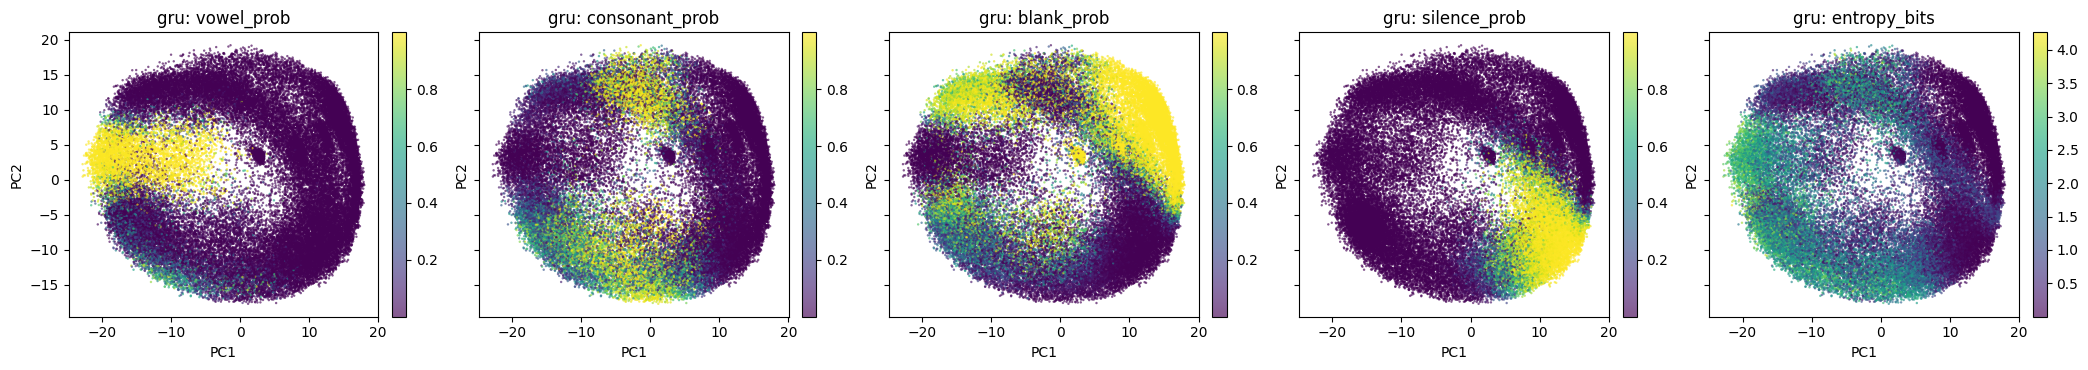

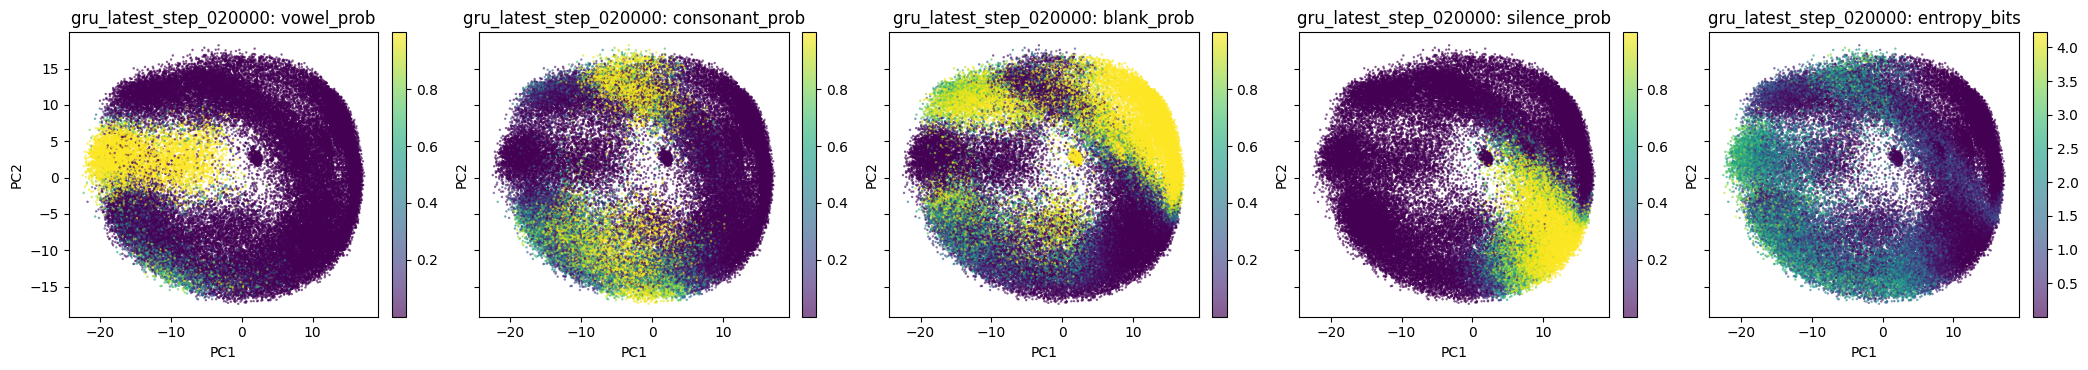

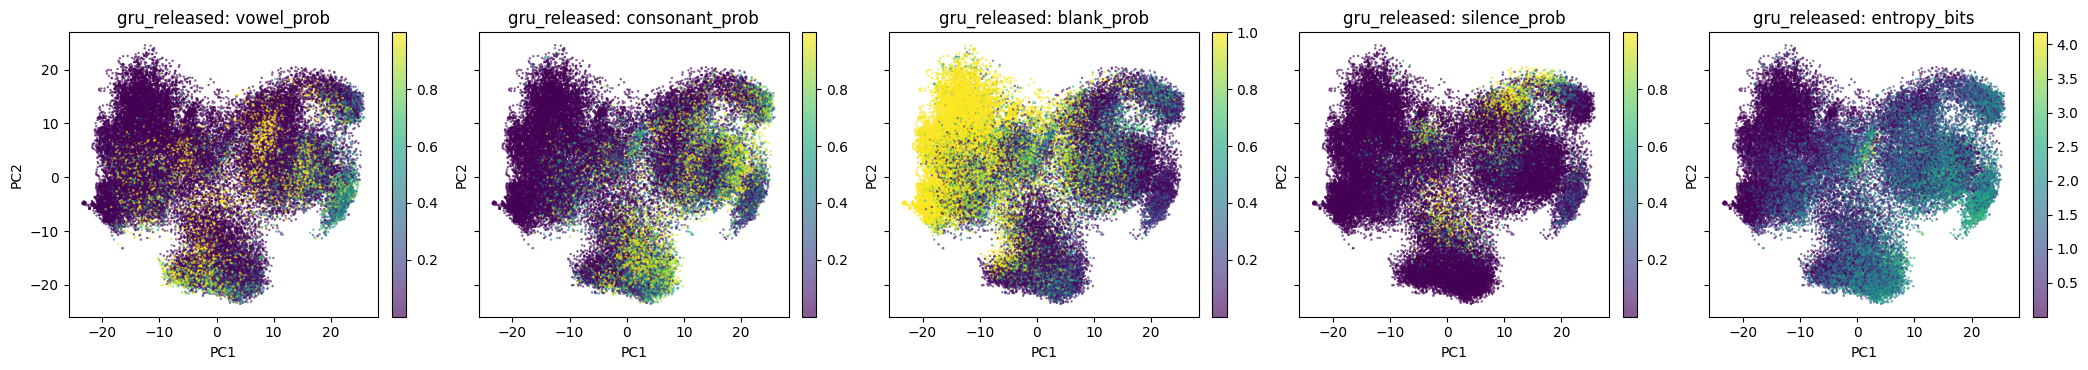

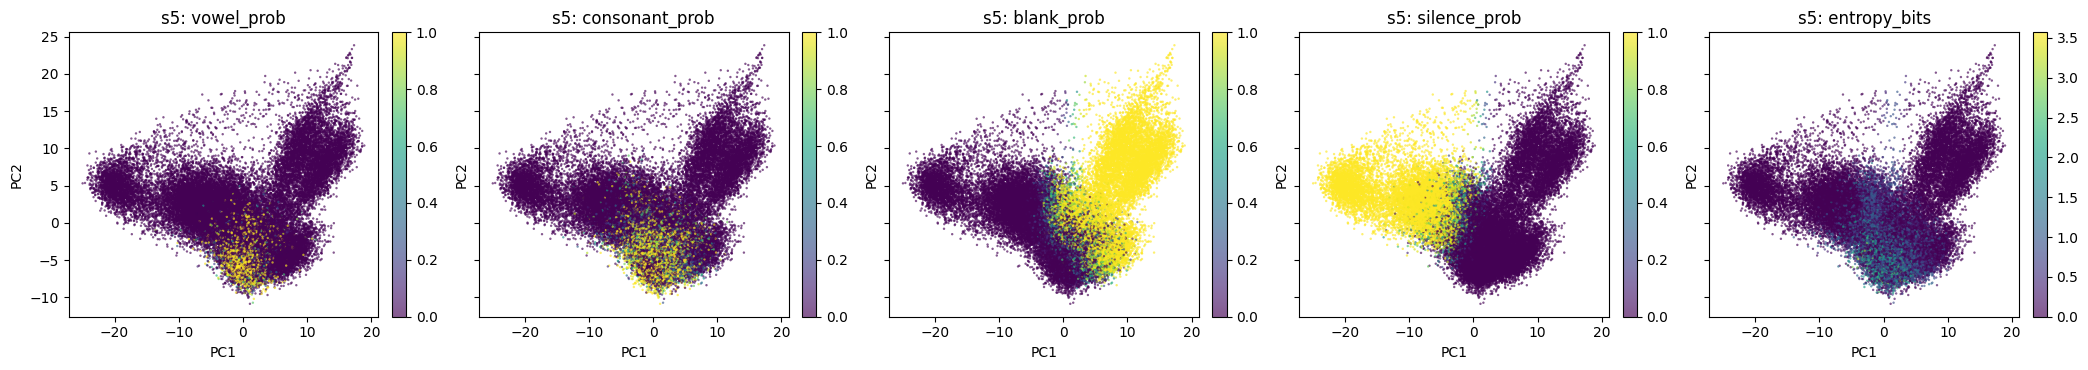

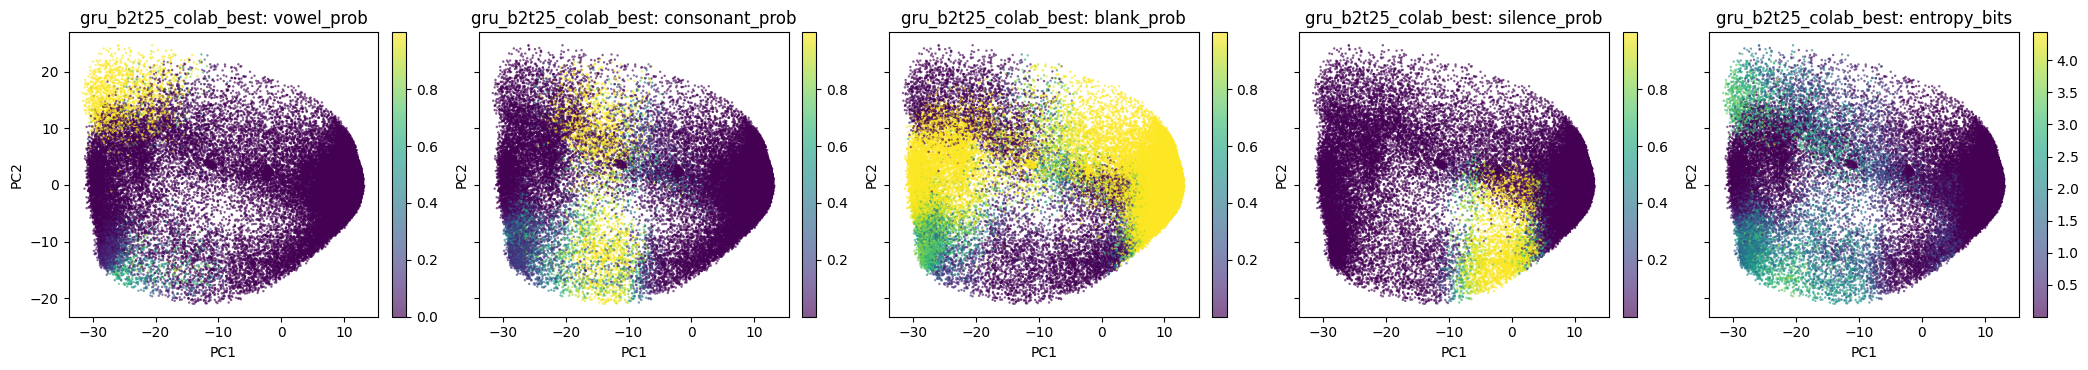

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def fit_pca_view(hidden, max_points=60_000, seed=7):
    rng = np.random.default_rng(seed)
    n = hidden.shape[0]
    if n > max_points:
        idx = np.sort(rng.choice(n, size=max_points, replace=False))
    else:
        idx = np.arange(n)
    x = hidden[idx].astype(np.float32, copy=False)
    x = StandardScaler().fit_transform(x)
    pca = PCA(n_components=3, random_state=seed)
    pcs = pca.fit_transform(x)
    return idx, pcs, pca

plot_model_keys = (
    tuple(PLOT_MODEL_KEYS)
    if globals().get('PLOT_MODEL_KEYS') is not None
    else tuple(exports)
)
missing_plot_keys = [model_key for model_key in plot_model_keys if model_key not in exports]
if missing_plot_keys:
    raise KeyError(f'PLOT_MODEL_KEYS contains models that were not loaded: {missing_plot_keys}')

pca_payloads = {}
for model_key in plot_model_keys:
    payload = exports[model_key]
    idx, pcs, pca = fit_pca_view(payload['hidden'])
    frame = payload['tokens'].iloc[idx].reset_index(drop=True).copy()
    frame['pc1'] = pcs[:, 0]
    frame['pc2'] = pcs[:, 1]
    frame['pc3'] = pcs[:, 2]
    pca_payloads[model_key] = {'frame': frame, 'pca': pca, 'indices': idx}
    print(model_key, 'explained variance:', np.round(pca.explained_variance_ratio_, 4))

color_columns = ['vowel_prob', 'consonant_prob', 'blank_prob', 'silence_prob', 'entropy_bits']
for model_key in plot_model_keys:
    p = pca_payloads[model_key]
    frame = p['frame']
    fig, axes = plt.subplots(1, len(color_columns), figsize=(4.2 * len(color_columns), 3.8), sharex=True, sharey=True)
    for ax, column in zip(axes, color_columns):
        sc = ax.scatter(frame['pc1'], frame['pc2'], c=frame[column], s=3, cmap='viridis', alpha=0.65, linewidths=0)
        ax.set_title(f'{model_key}: {column}')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## Matched Raw-Input PCA Baseline

This is the direct control for the hidden-state PCA above: it fits PCA to the raw neural input windows for the same frames, then colors those points using the GRU's logits-derived probabilities. It therefore tests whether a structure such as the vowel zone was already visible in the neural inputs before the GRU transformed them.


gru_b2t25_colab_best: input_windows; 60,000 frames; reused hidden-state PCA sample; explained variance [0.1123 0.0229 0.0155]


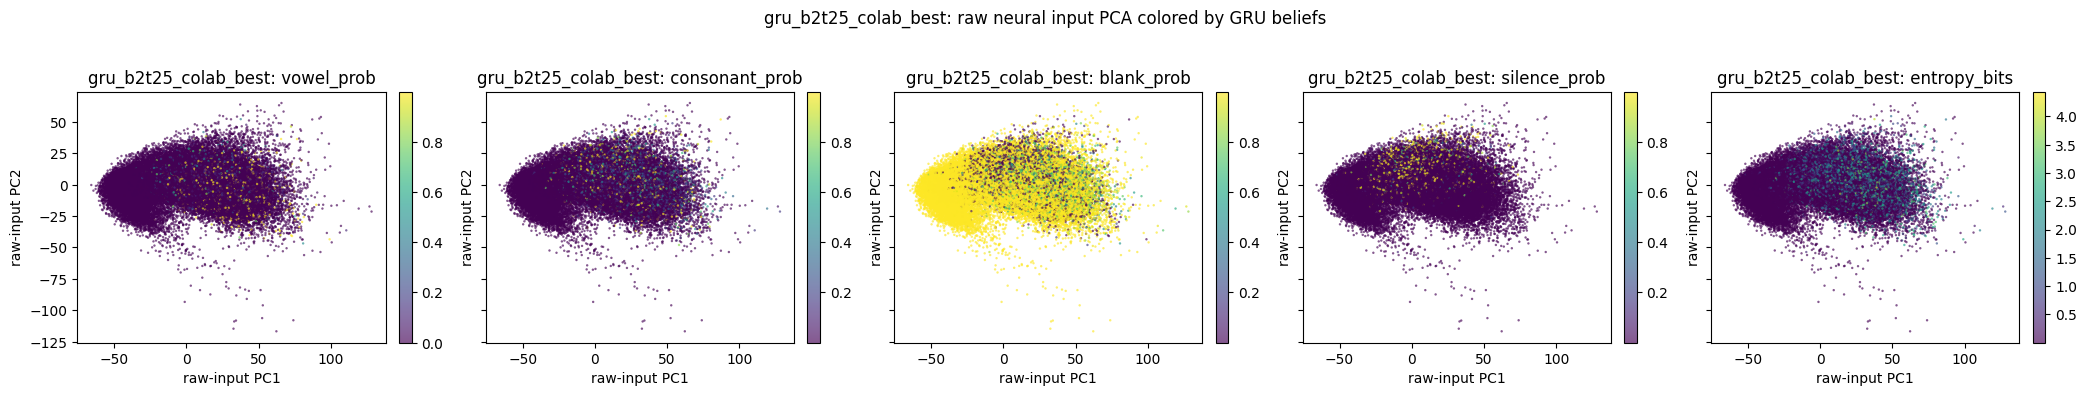

In [ ]:
# Choose the same checkpoint shown in the GRU PCA above.
RAW_BASELINE_MODEL_KEY = next((key for key in ('gru_b2t25_colab_best', 'gru_released', 'gru') if key in exports), next(iter(exports)))
RAW_BASELINE_WINDOW_KEY = 'input_windows'  # Set to 'adapted_input_windows' for the post-adapter control.
RAW_BASELINE_MAX_POINTS = 60_000
RAW_BASELINE_RANDOM_STATE = 7

if exports[RAW_BASELINE_MODEL_KEY].get(RAW_BASELINE_WINDOW_KEY) is None:
    exports[RAW_BASELINE_MODEL_KEY] = load_model_export(
        export_root_for_model(RAW_BASELINE_MODEL_KEY),
        RAW_BASELINE_MODEL_KEY,
        load_input_windows=True,
    )

# Reuse the hidden-state PCA sample whenever it exists, so the two panels differ
# only in the representation being projected. Fall back to the same seeded sampling rule.
hidden_pca_sample = pca_payloads.get(RAW_BASELINE_MODEL_KEY, {}).get('indices')
n_tokens = len(exports[RAW_BASELINE_MODEL_KEY]['tokens'])
if hidden_pca_sample is not None:
    baseline_indices = np.asarray(hidden_pca_sample, dtype=np.int64)
    sample_source = 'reused hidden-state PCA sample'
else:
    rng = np.random.default_rng(RAW_BASELINE_RANDOM_STATE)
    baseline_indices = (
        np.sort(rng.choice(n_tokens, size=RAW_BASELINE_MAX_POINTS, replace=False))
        if n_tokens > RAW_BASELINE_MAX_POINTS
        else np.arange(n_tokens)
    )
    sample_source = 'seeded all-frame sample'

baseline_windows = exports[RAW_BASELINE_MODEL_KEY][RAW_BASELINE_WINDOW_KEY][baseline_indices].astype(np.float32, copy=False)
baseline_pca = PCA(n_components=3, svd_solver='randomized', random_state=RAW_BASELINE_RANDOM_STATE)
baseline_pcs = baseline_pca.fit_transform(StandardScaler().fit_transform(baseline_windows))
raw_baseline_frame = exports[RAW_BASELINE_MODEL_KEY]['tokens'].iloc[baseline_indices].reset_index(drop=True).copy()
raw_baseline_frame['pc1'] = baseline_pcs[:, 0]
raw_baseline_frame['pc2'] = baseline_pcs[:, 1]
raw_baseline_frame['pc3'] = baseline_pcs[:, 2]

print(
    f'{RAW_BASELINE_MODEL_KEY}: {RAW_BASELINE_WINDOW_KEY}; {len(raw_baseline_frame):,} frames; {sample_source}; '
    f'explained variance {np.round(baseline_pca.explained_variance_ratio_, 4)}'
)

baseline_color_columns = ['vowel_prob', 'consonant_prob', 'blank_prob', 'silence_prob', 'entropy_bits']
fig, axes = plt.subplots(1, len(baseline_color_columns), figsize=(4.2 * len(baseline_color_columns), 3.8), sharex=True, sharey=True)
for ax, column in zip(axes, baseline_color_columns):
    sc = ax.scatter(
        raw_baseline_frame['pc1'], raw_baseline_frame['pc2'],
        c=raw_baseline_frame[column], s=3, cmap='viridis', alpha=0.65, linewidths=0,
    )
    ax.set_title(f'{RAW_BASELINE_MODEL_KEY}: {column}')
    ax.set_xlabel('raw-input PC1')
    ax.set_ylabel('raw-input PC2')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle(f'{RAW_BASELINE_MODEL_KEY}: raw neural input PCA colored by GRU beliefs', y=1.03)
plt.tight_layout()
plt.show()


## Save Analysis Tables

Optional compact outputs for later plotting outside the notebook.

In [ ]:
ANALYSIS_DIR = EXPORT_ROOT / 'analysis_tables'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

for model_key, payload in exports.items():
    tokens = payload['tokens']
    summary = tokens.groupby('top_category').agg(
        token_count=('global_token_index', 'count'),
        mean_top1_prob=('top1_prob', 'mean'),
        mean_entropy_bits=('entropy_bits', 'mean'),
        mean_vowel_prob=('vowel_prob', 'mean'),
        mean_consonant_prob=('consonant_prob', 'mean'),
    ).reset_index()
    summary.to_csv(ANALYSIS_DIR / f'{model_key}_category_summary.csv', index=False)

    if model_key in pca_payloads:
        pca_payloads[model_key]['frame'].to_csv(ANALYSIS_DIR / f'{model_key}_pca_sample.csv', index=False)

print('Saved analysis tables to:', ANALYSIS_DIR)

In [4]:
from google.colab import runtime
runtime.unassign()